
# FIFA23 BIGDATA 
## Data Cleaning • Data Normalization • Feature Engineering • Dimensionality Reduction (SVD)
- Không sửa dữ liệu gốc
- Mỗi bước đều lưu version
- Có note giải thích rõ trong từng Bước
- Có full-dataset profiling theo batch an toàn RAM
- Có cleaning
- Có normalization
- Có feature engineering
- Có SVD
- Có visualization
- Có insight
- Có output thực tế: **player similarity / scouting recommendation**
- đã tối ưu RAM:
  - không tạo similarity matrix `N x N`
  - không bung toàn bộ `feature_names` sau one-hot

## Bài toán cụ thể
Dataset FIFA có nhiều biến về:
- kỹ năng
- thể chất
- giá trị cầu thủ
- lương
- CLB
- quốc tịch
- vị trí thi đấu

Bài toán cụ thể của notebook này là:

**Scouting / Player Similarity Analysis**

Tức là:
1. làm sạch và chuẩn hóa dữ liệu cầu thủ
2. giảm chiều dữ liệu nhiều biến bằng SVD
3. đưa cầu thủ vào một latent space gọn hơn
4. tìm cầu thủ tương tự để hỗ trợ:
   - scouting
   - thay thế cầu thủ
   - hiểu cấu trúc ẩn của dữ liệu

##  giải quyết cái gì
Nó giải quyết 3 vấn đề:
1. dữ liệu gốc lớn, lẫn lộn, nhiều cột, khó xử lý trực tiếp
2. dữ liệu nhiều chiều nên khó trực quan hóa và so sánh
3. cần output có ý nghĩa thực tế 
## Trong README sẽ nói rõ hơn


In [ ]:

# Bước 1 - CÀI THƯ VIỆN + MOUNT DRIVE + KHAI BÁO PATH
# Mục đích:
# - Cài thư viện cần thiết cho cleaning, normalization, SVD
# - Kết nối Google Drive
# - Giữ nguyên DATA_DIR theo yêu cầu
# - Tạo thư mục output để lưu version từng bước
# - Không sửa dữ liệu gốc

!pip -q install pyarrow fastparquet unidecode scikit-learn

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

from unidecode import unidecode
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

# GIỮ NGUYÊN THEO YÊU CẦU CỦA BẠN
DATA_DIR = "/content/drive/MyDrive/FIFA23_BIGDATA"

# Tạo thư mục output để lưu các version qua từng bước
OUTPUT_DIR = os.path.join(DATA_DIR, "_processed_versions")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR =", DATA_DIR)
print("OUTPUT_DIR =", OUTPUT_DIR)
print("Folder exists:", os.path.exists(DATA_DIR))

# Kiểm tra nhanh folder có tồn tại không
if os.path.exists(DATA_DIR):
    print("Top-level content:", os.listdir(DATA_DIR)[:30])
else:
    raise FileNotFoundError(f"Không tồn tại folder: {DATA_DIR}")


Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/FIFA23_BIGDATA
OUTPUT_DIR = /content/drive/MyDrive/FIFA23_BIGDATA/_processed_versions
Folder exists: True
Top-level content: ['male_teams.csv', 'male_players.csv', 'SILVER', 'MODELS', 'GOLD', 'BRONZE', '_processed_versions']


In [ ]:

# Bước 2 - DÒ CẤU TRÚC DATASET
# Mục đích:
# - Tìm data thật bên trong DATA_DIR
# - Xác định dataset đang ở dạng file đơn hay parquet dataset folder
# - Tránh chạy nhầm khi folder chỉ có shortcut hoặc chỉ có _processed_versions

def scan_dataset_structure(data_dir: str, max_show=50):
    found = []
    for root, dirs, files in os.walk(data_dir):
        parquet_parts = [f for f in files if f.endswith(".parquet")]
        csvs = [f for f in files if f.lower().endswith(".csv")]
        excels = [f for f in files if f.lower().endswith((".xlsx", ".xls"))]
        if parquet_parts or csvs or excels:
            found.append({
                "root": root,
                "n_parquet": len(parquet_parts),
                "n_csv": len(csvs),
                "n_excel": len(excels),
                "sample_files": (parquet_parts + csvs + excels)[:5]
            })
    return found[:max_show]

structure = scan_dataset_structure(DATA_DIR)
print("Số thư mục có dấu hiệu chứa data:", len(structure))

for item in structure[:20]:
    print("\nROOT:", item["root"])
    print("n_parquet:", item["n_parquet"], "| n_csv:", item["n_csv"], "| n_excel:", item["n_excel"])
    print("sample_files:", item["sample_files"])

if len(structure) == 0:
    raise FileNotFoundError(
        "Không thấy file dữ liệu thật trong DATA_DIR. Nếu chỉ thấy _processed_versions thì folder hiện tại chưa chứa dataset thật."
    )

def find_data_source(data_dir: str):
    # Ưu tiên thư mục parquet dataset có nhiều file part
    parquet_dirs = []
    for root, dirs, files in os.walk(data_dir):
        part_files = [f for f in files if f.endswith(".parquet") and f.startswith("part-")]
        if len(part_files) > 0:
            parquet_dirs.append((root, len(part_files)))
    if parquet_dirs:
        parquet_dirs = sorted(parquet_dirs, key=lambda x: x[1], reverse=True)
        return ("parquet_dir", parquet_dirs[0][0], parquet_dirs[0][1])

    # Fallback: chọn file dữ liệu đơn lớn nhất
    candidate_files = []
    for root, dirs, files in os.walk(data_dir):
        for f in files:
            fp = os.path.join(root, f)
            if f.lower().endswith((".csv", ".parquet", ".xlsx", ".xls")):
                candidate_files.append((fp, os.path.getsize(fp)))
    if candidate_files:
        candidate_files = sorted(candidate_files, key=lambda x: x[1], reverse=True)
        return ("file", candidate_files[0][0], 1)

    raise FileNotFoundError("Không tìm thấy nguồn dữ liệu phù hợp.")

SOURCE_TYPE, SOURCE_PATH, SOURCE_COUNT = find_data_source(DATA_DIR)
print("\nSOURCE_TYPE =", SOURCE_TYPE)
print("SOURCE_PATH =", SOURCE_PATH)
print("SOURCE_COUNT =", SOURCE_COUNT)


Số thư mục có dấu hiệu chứa data: 12

ROOT: /content/drive/MyDrive/FIFA23_BIGDATA
n_parquet: 0 | n_csv: 2 | n_excel: 0
sample_files: ['male_teams.csv', 'male_players.csv']

ROOT: /content/drive/MyDrive/FIFA23_BIGDATA/SILVER/players_silver
n_parquet: 24 | n_csv: 0 | n_excel: 0
sample_files: ['part-00001-036910cc-907e-4b76-bdbd-a140432d8989-c000.snappy.parquet', 'part-00000-66188013-b3b8-4d7c-bd3a-3a708dfaa2a7-c000.snappy.parquet', 'part-00002-e0c2c449-ff04-4770-89d6-907c22483b4b-c000.snappy.parquet', 'part-00003-387db704-ebca-459c-9052-40c4dc3fcfdf-c000.snappy.parquet', 'part-00004-a4dde8d3-7a73-4f6a-a79b-1244c422653b-c000.snappy.parquet']

ROOT: /content/drive/MyDrive/FIFA23_BIGDATA/MODELS/overall_predict_gbt/treesMetadata
n_parquet: 1 | n_csv: 0 | n_excel: 0
sample_files: ['part-00000-820584c7-e982-43bd-8f46-abb8698a4258-c000.snappy.parquet']

ROOT: /content/drive/MyDrive/FIFA23_BIGDATA/MODELS/overall_predict_gbt/data
n_parquet: 1 | n_csv: 0 | n_excel: 0
sample_files: ['part-00000-d4f

In [ ]:

# Bước 3 - ĐỌC SCHEMA TOÀN DATASET
# Mục đích:
# - Xem toàn bộ cột của dataset trước khi đọc sample
# - Tránh kéo cả dataset lớn vào RAM
# - Chuẩn bị cho bước chọn cột modeling

if SOURCE_TYPE == "parquet_dir":
    dataset = ds.dataset(SOURCE_PATH, format="parquet")
    schema_names = dataset.schema.names
else:
    ext = Path(SOURCE_PATH).suffix.lower()
    if ext == ".parquet":
        dataset = ds.dataset(SOURCE_PATH, format="parquet")
        schema_names = dataset.schema.names
    elif ext == ".csv":
        schema_names = list(pd.read_csv(SOURCE_PATH, nrows=5, low_memory=False).columns)
    elif ext in [".xlsx", ".xls"]:
        schema_names = list(pd.read_excel(SOURCE_PATH, nrows=5).columns)
    else:
        raise ValueError("Không hỗ trợ định dạng hiện tại.")

schema_path = os.path.join(OUTPUT_DIR, "schema_columns.json")
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(schema_names, f, ensure_ascii=False, indent=2)

print("Tổng số cột:", len(schema_names))
print("40 cột đầu:")
print(schema_names[:40])


Tổng số cột: 110
40 cột đầu:
['player_id', 'player_url', 'fifa_version', 'fifa_update', 'fifa_update_date', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'league_id', 'league_name', 'league_level', 'club_team_id', 'club_name', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags']


In [ ]:

# Bước 4 - PROFILING TOÀN DATASET (AN TOÀN RAM)
# Mục đích:
# - Quét full dataset theo batch, không kéo full data vào pandas
# - Đếm tổng số dòng
# - Đếm số null theo cột
# - Lưu báo cáo profiling toàn dataset
# - Đây là bằng chứng cho thấy pipeline có nhìn toàn cục dataset, không chỉ sample

FULL_PROFILE_ENABLED = True
FULL_PROFILE_BATCH_SIZE = 50000

def full_profile_parquet_dataset(parquet_dir: str, batch_size: int = 50000):
    dataset = ds.dataset(parquet_dir, format="parquet")
    cols = dataset.schema.names
    null_counts = {c: 0 for c in cols}
    row_count = 0

    # Scanner đọc theo batch để tránh nổ RAM
    scanner = dataset.scanner(batch_size=batch_size)
    for batch in scanner.to_batches():
        pdf = batch.to_pandas()
        row_count += len(pdf)
        batch_nulls = pdf.isna().sum()
        for c in pdf.columns:
            null_counts[c] += int(batch_nulls[c])

    dtypes = {name: str(dataset.schema.field(name).type) for name in cols}
    prof = pd.DataFrame({
        "column": cols,
        "dtype_from_schema": [dtypes[c] for c in cols],
        "null_count_full_scan": [null_counts[c] for c in cols],
        "null_ratio_full_scan": [round((null_counts[c] / row_count) * 100, 4) if row_count > 0 else np.nan for c in cols]
    }).sort_values(by="null_ratio_full_scan", ascending=False)

    return prof, row_count

full_profile_path = os.path.join(OUTPUT_DIR, "profiling_full_dataset.csv")

if FULL_PROFILE_ENABLED:
    if SOURCE_TYPE == "parquet_dir":
        full_profile_df, full_row_count = full_profile_parquet_dataset(SOURCE_PATH, FULL_PROFILE_BATCH_SIZE)
    else:
        ext = Path(SOURCE_PATH).suffix.lower()
        if ext == ".csv":
            tmp_df = pd.read_csv(SOURCE_PATH, low_memory=False)
        elif ext == ".parquet":
            tmp_df = pd.read_parquet(SOURCE_PATH)
        elif ext in [".xlsx", ".xls"]:
            tmp_df = pd.read_excel(SOURCE_PATH)
        else:
            raise ValueError("Không hỗ trợ định dạng hiện tại.")

        full_row_count = len(tmp_df)
        full_profile_df = pd.DataFrame({
            "column": tmp_df.columns,
            "dtype_from_schema": tmp_df.dtypes.astype(str).values,
            "null_count_full_scan": tmp_df.isna().sum().values,
            "null_ratio_full_scan": (tmp_df.isna().mean().values * 100).round(4)
        }).sort_values(by="null_ratio_full_scan", ascending=False)

    full_profile_df.to_csv(full_profile_path, index=False)
    print("Tổng số dòng full scan:", full_row_count)
    print("Đã lưu full profiling:", full_profile_path)
    display(full_profile_df.head(30))
else:
    print("Đang tắt full profiling.")


Tổng số dòng full scan: 10003590
Đã lưu full profiling: /content/drive/MyDrive/FIFA23_BIGDATA/_processed_versions/profiling_full_dataset.csv


,column,dtype_from_schema,null_count_full_scan,null_ratio_full_scan
28,nation_team_id,int32,9410000,94.0662
29,nation_position,string,9410000,94.0662
30,nation_jersey_number,int32,9410000,94.0662
23,club_loaned_from,string,9299422,92.9608
39,player_tags,string,9238676,92.3536
81,goalkeeping_speed,int32,8882723,88.7954
40,player_traits,string,5353356,53.5143
38,release_clause_eur,int32,4094223,40.9275
72,mentality_composure,int32,1948724,19.4802
41,pace,int32,1121112,11.2071


In [ ]:

# Bước 5 - CHỌN CỘT QUAN TRỌNG + CỘT DATE/TEXT/CURRENCY + KÍCH THƯỚC MẪU
# Mục đích:
# - Chọn cột phục vụ bài toán scouting / similarity / SVD
# - Chủ động kéo thêm cột ngày tháng nếu có
# - Chủ động kéo thêm cột tiền tệ nếu có
# - Giới hạn số dòng sample để vừa đủ đại diện mà vẫn không nổ RAM

preferred_cols = [
    "sofifa_id", "short_name", "long_name", "player_positions", "overall", "potential",
    "value_eur", "wage_eur", "release_clause_eur", "age", "height_cm", "weight_kg",
    "club_name", "league_name", "nationality_name", "preferred_foot", "work_rate",
    "pace", "shooting", "passing", "dribbling", "defending", "physic",
    "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy",
    "attacking_short_passing", "attacking_volleys", "skill_dribbling",
    "skill_curve", "skill_fk_accuracy", "skill_long_passing", "skill_ball_control",
    "movement_acceleration", "movement_sprint_speed", "movement_agility",
    "movement_reactions", "movement_balance", "power_shot_power", "power_jumping",
    "power_stamina", "power_strength", "power_long_shots", "mentality_aggression",
    "mentality_interceptions", "mentality_positioning", "mentality_vision",
    "mentality_penalties", "mentality_composure"
]

# Tự tìm cột ngày tháng theo tên
date_keywords = ["date", "joined", "contract", "birth", "release", "updated", "valid_until"]
date_cols = [c for c in schema_names if any(k in c.lower() for k in date_keywords)]

# Tự tìm cột tiền tệ / giá trị / phí theo tên
currency_keywords = ["value", "wage", "salary", "release_clause", "fee", "price"]
currency_cols = [c for c in schema_names if any(k in c.lower() for k in currency_keywords)]

selected_cols = []
for c in preferred_cols + date_cols + currency_cols:
    if c in schema_names and c not in selected_cols:
        selected_cols.append(c)

# Nếu match quá ít cột, fallback sang 50 cột đầu
if len(selected_cols) < 15:
    selected_cols = schema_names[:50]

# Có thể giảm xuống 50000 hoặc 30000 nếu runtime yếu hơn
MAX_ROWS = 100000

selected_cols_path = os.path.join(OUTPUT_DIR, "selected_columns_for_modeling.json")
with open(selected_cols_path, "w", encoding="utf-8") as f:
    json.dump(selected_cols, f, ensure_ascii=False, indent=2)

print("Số cột được chọn:", len(selected_cols))
print("selected_cols =", selected_cols)
print("MAX_ROWS =", MAX_ROWS)


Số cột được chọn: 52
selected_cols = ['short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'release_clause_eur', 'age', 'height_cm', 'weight_kg', 'club_name', 'league_name', 'nationality_name', 'preferred_foot', 'work_rate', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure', 'fifa_update', 'fifa_update_date', 'club_joined_date', 'club_contract_valid_until_year']
MAX_ROWS

In [ ]:

# Bước 6 - ĐỌC SAMPLE DỮ LIỆU AN TOÀN RAM
# Mục đích:
# - Lấy sample từ dataset thật
# - Không sửa dữ liệu gốc
# - Tạo snapshot v0 để đối chiếu về sau

if SOURCE_TYPE == "parquet_dir":
    dataset = ds.dataset(SOURCE_PATH, format="parquet")
    table = dataset.head(MAX_ROWS, columns=selected_cols)
    df_raw = table.to_pandas()
else:
    ext = Path(SOURCE_PATH).suffix.lower()
    if ext == ".csv":
        df_raw = pd.read_csv(SOURCE_PATH, usecols=selected_cols, nrows=MAX_ROWS, low_memory=False)
    elif ext == ".parquet":
        df_raw = pd.read_parquet(SOURCE_PATH, columns=selected_cols).head(MAX_ROWS).copy()
    elif ext in [".xlsx", ".xls"]:
        df_raw = pd.read_excel(SOURCE_PATH, usecols=selected_cols, nrows=MAX_ROWS)
    else:
        raise ValueError("Không hỗ trợ định dạng hiện tại.")

raw_csv = os.path.join(OUTPUT_DIR, "v0_raw_sample_snapshot.csv")
raw_parquet = os.path.join(OUTPUT_DIR, "v0_raw_sample_snapshot.parquet")
df_raw.to_csv(raw_csv, index=False)
df_raw.to_parquet(raw_parquet, index=False)

print("Shape sample:", df_raw.shape)
display(df_raw.head())
print("Đã lưu:", raw_csv)
print("Đã lưu:", raw_parquet)


Shape sample: (100000, 52)


,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,release_clause_eur,age,height_cm,weight_kg,club_name,league_name,nationality_name,preferred_foot,work_rate,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,fifa_update,fifa_update_date,club_joined_date,club_contract_valid_until_year
0,L. Messi,Lionel Andrés Messi Cuccittini,RW,91,91,54000000.0,195000.0,99900000.0,35,169,67,Paris Saint Germain,Ligue 1,Argentina,Left,Low/Low,81.0,89.0,90.0,94.0,34.0,64.0,84,90,70,91,88,95,93,93,90,93,87,76,91,92,95,86,68,70,68,91,44,40,93,94,75,96,9,2023-01-13,2021-08-10,2023.0
1,K. Benzema,Karim Benzema,"CF, ST",91,91,64000000.0,450000.0,131200000.0,34,185,81,Real Madrid,La Liga,France,Right,Medium/Medium,80.0,88.0,83.0,87.0,39.0,78.0,75,92,90,89,88,87,82,73,76,91,79,80,78,92,72,87,79,82,82,80,63,39,92,89,84,90,9,2023-01-13,2009-07-09,2023.0
2,R. Lewandowski,Robert Lewandowski,ST,91,91,84000000.0,420000.0,172200000.0,33,185,81,FC Barcelona,La Liga,Poland,Right,High/Medium,75.0,91.0,79.0,86.0,44.0,83.0,71,94,91,84,89,85,79,85,70,89,76,75,77,93,82,91,85,76,87,84,81,49,94,81,90,88,9,2023-01-13,2022-07-18,2025.0
3,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,107500000.0,350000.0,198900000.0,31,181,75,Manchester City,Premier League,Belgium,Right,High/Medium,74.0,88.0,93.0,87.0,63.0,77.0,94,85,55,93,83,87,89,83,93,90,76,73,76,91,78,92,63,89,74,91,75,64,88,94,83,89,9,2023-01-13,2015-08-30,2025.0
4,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,95,190500000.0,230000.0,366700000.0,23,182,73,Paris Saint Germain,Ligue 1,France,Right,High/Low,97.0,89.0,80.0,92.0,36.0,76.0,78,93,72,85,83,93,80,69,71,91,97,97,93,93,81,88,77,87,76,82,64,38,92,83,80,88,9,2023-01-13,2018-07-01,2024.0


Đã lưu: /content/drive/MyDrive/FIFA23_BIGDATA/_processed_versions/v0_raw_sample_snapshot.csv
Đã lưu: /content/drive/MyDrive/FIFA23_BIGDATA/_processed_versions/v0_raw_sample_snapshot.parquet


In [ ]:

# Bước 7 - SAMPLE PROFILING BAN ĐẦU
# Mục đích:
# - Kiểm tra chất lượng sample trước cleaning
# - Xem kiểu dữ liệu, tỷ lệ thiếu, số unique, duplicate
# - Đây là cơ sở để quyết định cleaning hợp lý

sample_profile = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "null_count": df_raw.isna().sum().values,
    "null_ratio": (df_raw.isna().mean().values * 100).round(4),
    "n_unique": df_raw.nunique(dropna=True).values
}).sort_values(by=["null_ratio", "n_unique"], ascending=[False, False])

sample_profile_path = os.path.join(OUTPUT_DIR, "profiling_initial_sample.csv")
sample_profile.to_csv(sample_profile_path, index=False)

print("Tổng số ô thiếu trong sample:", int(df_raw.isna().sum().sum()))
print("Số dòng trùng hoàn toàn trong sample:", int(df_raw.duplicated().sum()))
display(sample_profile.head(30))


Tổng số ô thiếu trong sample: 83094
Số dòng trùng hoàn toàn trong sample: 0


,column,dtype,null_count,null_ratio,n_unique
20,defending,float64,11092,11.092,77
17,shooting,float64,11092,11.092,74
16,pace,float64,11092,11.092,70
18,passing,float64,11092,11.092,67
19,dribbling,float64,11092,11.092,67
21,physic,float64,11092,11.092,61
7,release_clause_eur,float64,7111,7.111,1356
50,club_joined_date,datetime64[ns],7053,7.053,1974
5,value_eur,float64,522,0.522,262
11,club_name,object,464,0.464,673


In [ ]:

# Bước 8 - DATA CLEANING + PARSE CURRENCY + DATE -> DATETIME
# Mục đích:
# - Làm sạch text
# - Xóa duplicate
# - Chuyển object -> numeric khi hợp lý
# - Parse cột tiền tệ dạng text nếu có
# - Parse cột ngày tháng sang datetime
# - Loại giá trị âm bất hợp lý
# - Fill missing cho numeric và categorical
# - Lưu version cleaned

df = df_raw.copy()

# Chuẩn hóa tên cột để xử lý dễ hơn
df.columns = [re.sub(r"\s+", "_", str(c).strip().lower()) for c in df.columns]

def clean_text_value(x):
    # Chuẩn hóa text:
    # - strip
    # - lowercase
    # - bỏ dấu tiếng Việt
    # - bỏ ký tự đặc biệt không cần thiết
    if pd.isna(x):
        return x
    x = str(x).strip().lower()
    x = unidecode(x)
    x = re.sub(r"[^a-z0-9\s\-_/\.]", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def parse_currency_text(series: pd.Series) -> pd.Series:
    # Hỗ trợ các dạng như €1.2M, 500K, $900000...
    s = series.astype(str).str.strip()
    multiplier = pd.Series(1.0, index=s.index)
    multiplier[s.str.contains("m", case=False, na=False)] = 1_000_000
    multiplier[s.str.contains("k", case=False, na=False)] = 1_000
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace(r"[^0-9\.\-]", "", regex=True)
    out = pd.to_numeric(s, errors="coerce") * multiplier
    return out

# Xóa duplicate
before_dup = len(df)
df = df.drop_duplicates()
after_dup = len(df)

# Làm sạch text cho object columns
obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in obj_cols:
    df[c] = df[c].apply(clean_text_value)

# Parse currency cho cột tiền tệ đang là object
for c in df.columns:
    if df[c].dtype == "object" and any(k in c.lower() for k in ["value", "wage", "salary", "release_clause", "fee", "price"]):
        parsed = parse_currency_text(df[c])
        if parsed.notna().mean() >= 0.60:
            df[c] = parsed

# Object -> numeric nếu đa số parse được
for c in df.columns:
    if df[c].dtype == "object":
        numeric_candidate = pd.to_numeric(df[c], errors="coerce")
        if numeric_candidate.notna().mean() >= 0.80:
            df[c] = numeric_candidate

# Parse date -> datetime
for c in df.columns:
    if any(k in c.lower() for k in ["date", "joined", "contract", "birth", "release", "updated", "valid_until"]):
        converted = pd.to_datetime(df[c], errors="coerce")
        if converted.notna().mean() >= 0.40:
            df[c] = converted

# Xử lý giá trị âm bất hợp lý
invalid_negative_keywords = [
    "age", "value", "wage", "height", "weight", "overall", "potential", "release_clause",
    "pace", "shooting", "passing", "dribbling", "defending", "physic",
    "crossing", "finishing", "heading", "short_passing", "volleys",
    "acceleration", "sprint", "agility", "reactions", "balance",
    "shot_power", "jumping", "stamina", "strength", "long_shots",
    "aggression", "interceptions", "positioning", "vision", "penalties", "composure"
]

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if any(k in c.lower() for k in invalid_negative_keywords):
        df.loc[df[c] < 0, c] = np.nan

# Fill missing
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
dt_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols + dt_cols]

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    mode_val = df[c].mode(dropna=True)
    fill_val = mode_val.iloc[0] if len(mode_val) > 0 else "unknown"
    df[c] = df[c].fillna(fill_val)

clean_csv = os.path.join(OUTPUT_DIR, "v1_cleaned_sample.csv")
clean_parquet = os.path.join(OUTPUT_DIR, "v1_cleaned_sample.parquet")
df.to_csv(clean_csv, index=False)
df.to_parquet(clean_parquet, index=False)

print("Duplicate removed:", before_dup - after_dup)
print("Shape sau cleaning:", df.shape)
print("Null sau cleaning:", int(df.isna().sum().sum()))
display(df.head())


Duplicate removed: 0
Shape sau cleaning: (100000, 52)
Null sau cleaning: 14628


,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,release_clause_eur,age,height_cm,weight_kg,club_name,league_name,nationality_name,preferred_foot,work_rate,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,fifa_update,fifa_update_date,club_joined_date,club_contract_valid_until_year
0,l. messi,lionel andres messi cuccittini,rw,91.0,91.0,54000000.0,195000.0,1970-01-01 00:00:00.099900,35.0,169.0,67.0,paris saint germain,ligue 1,argentina,left,low/low,81.0,89.0,90.0,94.0,34.0,64.0,84.0,90.0,70.0,91.0,88.0,95.0,93,93,90.0,93,87.0,76.0,91.0,92.0,95.0,86.0,68.0,70.0,68.0,91.0,44.0,40.0,93.0,94.0,75.0,96.0,1970-01-01 00:00:00.000000009,2023-01-13,2021-08-10,1970-01-01 00:00:00.000002023
1,k. benzema,karim benzema,cf st,91.0,91.0,64000000.0,450000.0,1970-01-01 00:00:00.131200,34.0,185.0,81.0,real madrid,la liga,france,right,medium/medium,80.0,88.0,83.0,87.0,39.0,78.0,75.0,92.0,90.0,89.0,88.0,87.0,82,73,76.0,91,79.0,80.0,78.0,92.0,72.0,87.0,79.0,82.0,82.0,80.0,63.0,39.0,92.0,89.0,84.0,90.0,1970-01-01 00:00:00.000000009,2023-01-13,2009-07-09,1970-01-01 00:00:00.000002023
2,r. lewandowski,robert lewandowski,st,91.0,91.0,84000000.0,420000.0,1970-01-01 00:00:00.172200,33.0,185.0,81.0,fc barcelona,la liga,poland,right,high/medium,75.0,91.0,79.0,86.0,44.0,83.0,71.0,94.0,91.0,84.0,89.0,85.0,79,85,70.0,89,76.0,75.0,77.0,93.0,82.0,91.0,85.0,76.0,87.0,84.0,81.0,49.0,94.0,81.0,90.0,88.0,1970-01-01 00:00:00.000000009,2023-01-13,2022-07-18,1970-01-01 00:00:00.000002025
3,k. de bruyne,kevin de bruyne,cm cam,91.0,91.0,107500000.0,350000.0,1970-01-01 00:00:00.198900,31.0,181.0,75.0,manchester city,premier league,belgium,right,high/medium,74.0,88.0,93.0,87.0,63.0,77.0,94.0,85.0,55.0,93.0,83.0,87.0,89,83,93.0,90,76.0,73.0,76.0,91.0,78.0,92.0,63.0,89.0,74.0,91.0,75.0,64.0,88.0,94.0,83.0,89.0,1970-01-01 00:00:00.000000009,2023-01-13,2015-08-30,1970-01-01 00:00:00.000002025
4,k. mbappe,kylian mbappe lottin,st lw,91.0,95.0,190500000.0,230000.0,1970-01-01 00:00:00.366700,23.0,182.0,73.0,paris saint germain,ligue 1,france,right,high/low,97.0,89.0,80.0,92.0,36.0,76.0,78.0,93.0,72.0,85.0,83.0,93.0,80,69,71.0,91,97.0,97.0,93.0,93.0,81.0,88.0,77.0,87.0,76.0,82.0,64.0,38.0,92.0,83.0,80.0,88.0,1970-01-01 00:00:00.000000009,2023-01-13,2018-07-01,1970-01-01 00:00:00.000002024


In [ ]:

# Bước 9 - FEATURE ENGINEERING
# Mục đích:
# - Tạo thêm biến có ý nghĩa cho bài toán scouting / similarity
# - Tách datetime thành year/month/day
# - Tạo BMI
# - Tạo potential_gap
# - Tạo value_per_overall
# - Rút gọn nhóm vị trí để dễ phân tích

df_fe = df.copy()

# Datetime -> year/month/day
dt_cols = df_fe.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
for c in dt_cols:
    df_fe[f"{c}_year"] = df_fe[c].dt.year
    df_fe[f"{c}_month"] = df_fe[c].dt.month
    df_fe[f"{c}_day"] = df_fe[c].dt.day
    # Chuẩn hóa format ngày để lưu/readme rõ ràng
    df_fe[c] = df_fe[c].dt.strftime("%Y-%m-%d")

# BMI
if "height_cm" in df_fe.columns and "weight_kg" in df_fe.columns:
    height_m = df_fe["height_cm"] / 100
    df_fe["bmi"] = np.where(height_m > 0, df_fe["weight_kg"] / (height_m ** 2), np.nan)

# Potential gap
if "potential" in df_fe.columns and "overall" in df_fe.columns:
    df_fe["potential_gap"] = df_fe["potential"] - df_fe["overall"]

# Value per overall
if "value_eur" in df_fe.columns and "overall" in df_fe.columns:
    df_fe["value_per_overall"] = np.where(df_fe["overall"] > 0, df_fe["value_eur"] / df_fe["overall"], np.nan)

# Rút gọn nhóm vị trí
if "player_positions" in df_fe.columns:
    def map_position_group(x):
        if pd.isna(x):
            return "unknown"
        s = str(x).lower()
        if any(p in s for p in ["st", "cf", "lw", "rw", "lf", "rf"]):
            return "forward"
        if any(p in s for p in ["cam", "cm", "cdm", "lm", "rm"]):
            return "midfielder"
        if any(p in s for p in ["cb", "lb", "rb", "lwb", "rwb"]):
            return "defender"
        if "gk" in s:
            return "goalkeeper"
        return "other"
    df_fe["position_group"] = df_fe["player_positions"].apply(map_position_group)

# Fill missing phát sinh sau feature engineering
num_cols_fe = df_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_fe = df_fe.select_dtypes(include=["object"]).columns.tolist()

for c in num_cols_fe:
    df_fe[c] = df_fe[c].fillna(df_fe[c].median())

for c in cat_cols_fe:
    mode_val = df_fe[c].mode(dropna=True)
    fill_val = mode_val.iloc[0] if len(mode_val) > 0 else "unknown"
    df_fe[c] = df_fe[c].fillna(fill_val)

fe_csv = os.path.join(OUTPUT_DIR, "v2_feature_engineered_sample.csv")
fe_parquet = os.path.join(OUTPUT_DIR, "v2_feature_engineered_sample.parquet")
df_fe.to_csv(fe_csv, index=False)
df_fe.to_parquet(fe_parquet, index=False)

print("Shape sau feature engineering:", df_fe.shape)
display(df_fe.head())


Shape sau feature engineering: (100000, 71)


,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,release_clause_eur,age,height_cm,weight_kg,club_name,league_name,nationality_name,preferred_foot,work_rate,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,fifa_update,fifa_update_date,club_joined_date,club_contract_valid_until_year,release_clause_eur_year,release_clause_eur_month,release_clause_eur_day,fifa_update_year,fifa_update_month,fifa_update_day,fifa_update_date_year,fifa_update_date_month,fifa_update_date_day,club_joined_date_year,club_joined_date_month,club_joined_date_day,club_contract_valid_until_year_year,club_contract_valid_until_year_month,club_contract_valid_until_year_day,bmi,potential_gap,value_per_overall,position_group
0,l. messi,lionel andres messi cuccittini,rw,91.0,91.0,54000000.0,195000.0,1970-01-01,35.0,169.0,67.0,paris saint germain,ligue 1,argentina,left,low/low,81.0,89.0,90.0,94.0,34.0,64.0,84.0,90.0,70.0,91.0,88.0,95.0,93,93,90.0,93,87.0,76.0,91.0,92.0,95.0,86.0,68.0,70.0,68.0,91.0,44.0,40.0,93.0,94.0,75.0,96.0,1970-01-01,2023-01-13,2021-08-10,1970-01-01,1970.0,1.0,1.0,1970,1,1,2023,1,13,2021.0,8.0,10.0,1970.0,1.0,1.0,23.458562,0.0,5.934066e+05,forward
1,k. benzema,karim benzema,cf st,91.0,91.0,64000000.0,450000.0,1970-01-01,34.0,185.0,81.0,real madrid,la liga,france,right,medium/medium,80.0,88.0,83.0,87.0,39.0,78.0,75.0,92.0,90.0,89.0,88.0,87.0,82,73,76.0,91,79.0,80.0,78.0,92.0,72.0,87.0,79.0,82.0,82.0,80.0,63.0,39.0,92.0,89.0,84.0,90.0,1970-01-01,2023-01-13,2009-07-09,1970-01-01,1970.0,1.0,1.0,1970,1,1,2023,1,13,2009.0,7.0,9.0,1970.0,1.0,1.0,23.666910,0.0,7.032967e+05,forward
2,r. lewandowski,robert lewandowski,st,91.0,91.0,84000000.0,420000.0,1970-01-01,33.0,185.0,81.0,fc barcelona,la liga,poland,right,high/medium,75.0,91.0,79.0,86.0,44.0,83.0,71.0,94.0,91.0,84.0,89.0,85.0,79,85,70.0,89,76.0,75.0,77.0,93.0,82.0,91.0,85.0,76.0,87.0,84.0,81.0,49.0,94.0,81.0,90.0,88.0,1970-01-01,2023-01-13,2022-07-18,1970-01-01,1970.0,1.0,1.0,1970,1,1,2023,1,13,2022.0,7.0,18.0,1970.0,1.0,1.0,23.666910,0.0,9.230769e+05,forward
3,k. de bruyne,kevin de bruyne,cm cam,91.0,91.0,107500000.0,350000.0,1970-01-01,31.0,181.0,75.0,manchester city,premier league,belgium,right,high/medium,74.0,88.0,93.0,87.0,63.0,77.0,94.0,85.0,55.0,93.0,83.0,87.0,89,83,93.0,90,76.0,73.0,76.0,91.0,78.0,92.0,63.0,89.0,74.0,91.0,75.0,64.0,88.0,94.0,83.0,89.0,1970-01-01,2023-01-13,2015-08-30,1970-01-01,1970.0,1.0,1.0,1970,1,1,2023,1,13,2015.0,8.0,30.0,1970.0,1.0,1.0,22.893074,0.0,1.181319e+06,midfielder
4,k. mbappe,kylian mbappe lottin,st lw,91.0,95.0,190500000.0,230000.0,1970-01-01,23.0,182.0,73.0,paris saint germain,ligue 1,france,right,high/low,97.0,89.0,80.0,92.0,36.0,76.0,78.0,93.0,72.0,85.0,83.0,93.0,80,69,71.0,91,97.0,97.0,93.0,93.0,81.0,88.0,77.0,87.0,76.0,82.0,64.0,38.0,92.0,83.0,80.0,88.0,1970-01-01,2023-01-13,2018-07-01,1970-01-01,1970.0,1.0,1.0,1970,1,1,2023,1,13,2018.0,7.0,1.0,1970.0,1.0,1.0,22.038401,4.0,2.093407e+06,forward


In [ ]:

# Bước 10 - DATA NORMALIZATION + ENCODING
# Mục đích:
# - Chuẩn hóa numeric bằng StandardScaler
# - Mã hóa categorical bằng OneHotEncoder
# - Tạo ma trận X toàn số để đưa vào SVD
# - Chọn One-hot thay vì Label Encoding vì đa số categorical ở đây không có thứ tự tự nhiên

df_model = df_fe.copy()

# Chọn cột định danh để giữ lại cho output nhưng không dùng làm feature
id_candidates = ["short_name", "long_name", "name", "player_name", "sofifa_id", "id"]
id_col = next((c for c in id_candidates if c in df_model.columns), None)

numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()

feature_exclude = []
if id_col and id_col in numeric_cols + categorical_cols:
    feature_exclude.append(id_col)

numeric_features = [c for c in numeric_cols if c not in feature_exclude]
categorical_features = [c for c in categorical_cols if c not in feature_exclude]

print("id_col =", id_col)
print("numeric_features =", len(numeric_features))
print("categorical_features =", len(categorical_features))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

X = preprocessor.fit_transform(df_model)
print("Shape sau preprocessing:", X.shape)


id_col = short_name
numeric_features = 57
categorical_features = 13
Shape sau preprocessing: (100000, 23449)


In [ ]:

# Bước 11 - CHẠY SVD
# Mục đích:
# - Thử nhiều số chiều
# - Đo cumulative explained variance
# - Chọn số chiều tối ưu
# - Tạo embedding giảm chiều phục vụ visualization và similarity

max_components = min(30, X.shape[1] - 1) if X.shape[1] > 2 else 2
component_range = list(range(2, max_components + 1))

explained_records = []
for n in component_range:
    svd_tmp = TruncatedSVD(n_components=n, random_state=42)
    svd_tmp.fit(X)
    explained_records.append({
        "n_components": n,
        "explained_variance_ratio_sum": svd_tmp.explained_variance_ratio_.sum()
    })

explained_df = pd.DataFrame(explained_records)

# Chọn số chiều đầu tiên đạt ngưỡng 90% nếu có
target_variance = 0.90
eligible = explained_df[explained_df["explained_variance_ratio_sum"] >= target_variance]
best_n = int(eligible.iloc[0]["n_components"]) if len(eligible) > 0 else int(
    explained_df.sort_values("explained_variance_ratio_sum", ascending=False).iloc[0]["n_components"]
)

svd = TruncatedSVD(n_components=best_n, random_state=42)
X_svd = svd.fit_transform(X)

explained_path = os.path.join(OUTPUT_DIR, "svd_explained_variance_sample.csv")
explained_df.to_csv(explained_path, index=False)

print("best_n =", best_n)
print("Total explained variance =", svd.explained_variance_ratio_.sum())
display(explained_df.head())


best_n = 30
Total explained variance = 0.8643011256207699


,n_components,explained_variance_ratio_sum
0,2,0.427660
1,3,0.428482
2,4,0.501973
3,5,0.553249
4,6,0.592568


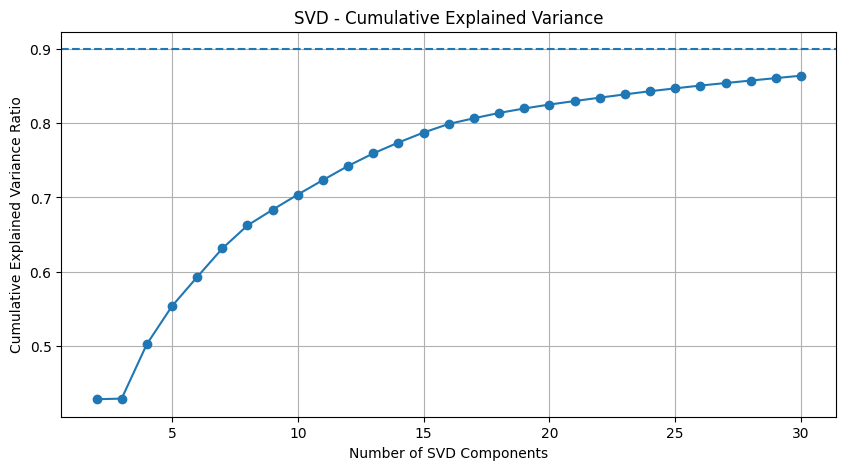

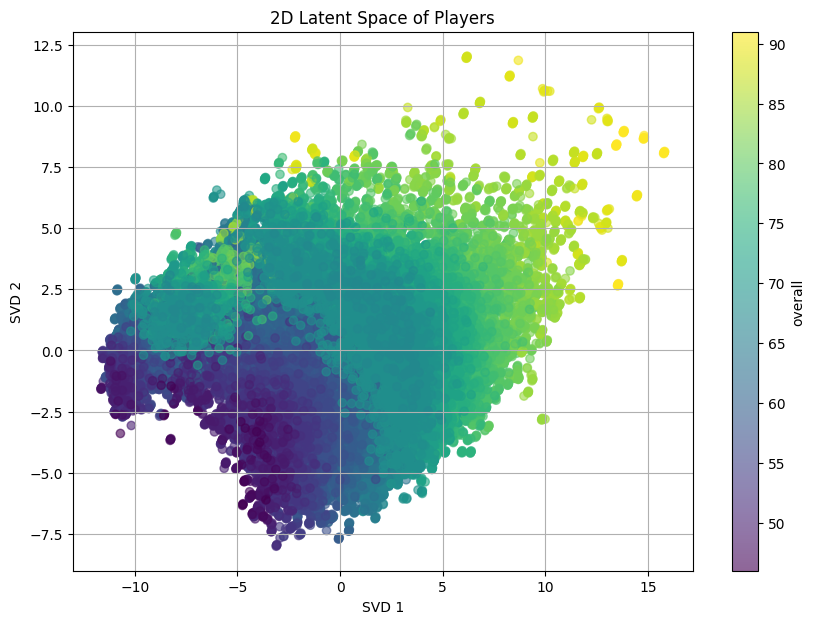

Đã lưu embedding:
/content/drive/MyDrive/FIFA23_BIGDATA/_processed_versions/v3_model_ready_embedding_sample.csv
/content/drive/MyDrive/FIFA23_BIGDATA/_processed_versions/v3_model_ready_embedding_sample.parquet


,svd_1,svd_2,svd_3,svd_4,svd_5,svd_6,svd_7,svd_8,svd_9,svd_10,svd_11,svd_12,svd_13,svd_14,svd_15,svd_16,svd_17,svd_18,svd_19,svd_20,svd_21,svd_22,svd_23,svd_24,svd_25,svd_26,svd_27,svd_28,svd_29,svd_30,short_name,overall,potential,value_eur,wage_eur,club_name,player_positions,preferred_foot,position_group,potential_gap
0,13.532074,2.650698,2.513768,8.497856,4.127789,-2.578562,2.432787,0.111678,4.666568,-1.098823,-2.066665,-0.756676,1.611612,1.881241,0.510670,-0.531197,0.954629,-0.077282,-0.892508,-0.007042,-1.172040,-0.253526,0.303496,1.312566,2.435559,-0.359173,0.096011,0.251179,-0.035436,0.297108,l. messi,91.0,91.0,54000000.0,195000.0,paris saint germain,rw,left,forward,0.0
1,13.450240,8.356295,3.254889,11.220634,6.849896,-5.828492,1.005857,0.550639,10.227324,-3.153374,-1.386024,-3.485995,1.081884,-1.394660,-2.164849,0.932129,1.542288,1.189305,0.073679,-3.066834,-2.632803,3.297798,-1.345902,3.604059,10.089338,-0.998016,0.240401,0.678679,-0.119666,0.679036,k. benzema,91.0,91.0,64000000.0,450000.0,real madrid,cf st,right,forward,0.0
2,13.809632,8.908332,3.135153,11.028654,7.136568,-7.705056,0.412301,0.020335,10.146587,-2.809444,-4.514438,-0.774838,2.359418,3.216184,-0.636513,2.401111,1.118161,-0.021710,0.218831,-2.677124,-2.538086,2.083123,-1.774690,2.274495,7.646346,-0.779351,0.123471,1.147215,-0.051386,0.111231,r. lewandowski,91.0,91.0,84000000.0,420000.0,fc barcelona,st,right,forward,0.0
3,14.787872,8.646973,3.153332,12.262736,9.830262,-4.785433,1.589888,-1.289710,10.889238,-2.882281,-4.748699,-1.191975,2.419903,0.637778,-3.302532,3.262059,0.497035,0.549485,0.359559,-0.986286,-1.172306,0.337599,-0.612310,0.978766,4.086891,-0.386011,0.080483,0.401070,0.001760,-0.133026,k. de bruyne,91.0,91.0,107500000.0,350000.0,manchester city,cm cam,right,midfielder,0.0
4,15.778907,8.053315,3.331076,15.701503,15.238718,-10.771199,-0.965655,0.776583,14.565236,-3.904301,-5.809937,-3.062752,1.287737,4.421112,-3.471587,5.188422,-0.572005,0.803029,-0.551241,1.985501,1.507783,-2.113663,1.566052,-1.294819,-6.544487,0.409949,-0.153229,-0.090462,0.099346,-0.613621,k. mbappe,91.0,95.0,190500000.0,230000.0,paris saint germain,st lw,right,forward,4.0


In [ ]:

# Bước 12 - OUTPUT EMBEDDING + VISUALIZATION
# Mục đích:
# - Lưu embedding sau SVD
# - Vẽ explained variance
# - Vẽ latent space 2D
# - Chuẩn bị dữ liệu cho insight và player similarity

svd_cols = [f"svd_{i+1}" for i in range(best_n)]
embedding_df = pd.DataFrame(X_svd, columns=svd_cols)

if id_col:
    embedding_df[id_col] = df_model[id_col].values

for c in ["overall", "potential", "value_eur", "wage_eur", "club_name", "player_positions", "preferred_foot", "position_group", "potential_gap"]:
    if c in df_model.columns:
        embedding_df[c] = df_model[c].values

embedding_csv = os.path.join(OUTPUT_DIR, "v3_model_ready_embedding_sample.csv")
embedding_parquet = os.path.join(OUTPUT_DIR, "v3_model_ready_embedding_sample.parquet")
embedding_df.to_csv(embedding_csv, index=False)
embedding_df.to_parquet(embedding_parquet, index=False)

# Biểu đồ cumulative explained variance
plt.figure(figsize=(10, 5))
plt.plot(explained_df["n_components"], explained_df["explained_variance_ratio_sum"], marker="o")
plt.axhline(target_variance, linestyle="--")
plt.xlabel("Number of SVD Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("SVD - Cumulative Explained Variance")
plt.grid(True)
plt.show()

# Biểu đồ latent space 2D
if best_n >= 2:
    plt.figure(figsize=(10, 7))
    if "overall" in embedding_df.columns:
        scatter = plt.scatter(embedding_df["svd_1"], embedding_df["svd_2"], c=embedding_df["overall"], alpha=0.6)
        plt.colorbar(scatter, label="overall")
    else:
        plt.scatter(embedding_df["svd_1"], embedding_df["svd_2"], alpha=0.6)
    plt.xlabel("SVD 1")
    plt.ylabel("SVD 2")
    plt.title("2D Latent Space of Players")
    plt.grid(True)
    plt.show()

print("Đã lưu embedding:")
print(embedding_csv)
print(embedding_parquet)
display(embedding_df.head())


In [ ]:

# Bước 13 - INSIGHT: TOP FEATURES + PLAYER SIMILARITY (NHẸ RAM)
# Mục đích:
# - Tạo output thực tế: tìm cầu thủ tương tự
# - Vẫn giữ insight cho SVD nhưng theo cách nhẹ RAM hơn
# - Do chạy thông thường sẽ làm nổ RAM nên đoạn này sẽ KHÔNG:
#   + tạo sim_matrix N x N
#   + gọi preprocessor.get_feature_names_out()
# - Vì hai thao tác đó rất dễ làm Colab hết RAM khi dữ liệu one-hot lớn

# -------------------------------
# PHẦN 1 - Insight nhẹ RAM
# -------------------------------
# Không lấy tên full feature sau one-hot vì rất nặng RAM.
# Chỉ lấy top trọng số theo index của feature trong không gian sau preprocessing.

component_index_importance = []
n_show_components = min(5, best_n)

for i in range(n_show_components):
    comp = svd.components_[i]
    abs_idx = np.argsort(np.abs(comp))[::-1][:15]
    for rank, idx in enumerate(abs_idx, start=1):
        component_index_importance.append({
            "component": f"svd_{i+1}",
            "rank": rank,
            "feature_index": int(idx),
            "weight": float(comp[idx]),
            "abs_weight": float(abs(comp[idx]))
        })

importance_df = pd.DataFrame(component_index_importance)
importance_path = os.path.join(OUTPUT_DIR, "svd_top_feature_importance_sample_light.csv")
importance_df.to_csv(importance_path, index=False)

print("Top feature importance theo index (nhẹ RAM):")
display(importance_df.head(30))

# -------------------------------
# PHẦN 2 - Player similarity
# -------------------------------
if id_col:
    # Ép float32 để tiết kiệm RAM
    latent_matrix = embedding_df[svd_cols].to_numpy(dtype=np.float32)

    # Chọn query player
    if "overall" in embedding_df.columns:
        query_idx = embedding_df["overall"].fillna(-1).astype(float).idxmax()
    else:
        query_idx = 0

    query_name = embedding_df.loc[query_idx, id_col]

    # Chỉ tính similarity từ 1 query tới toàn bộ dataset
    # Không tạo ma trận N x N
    query_vector = latent_matrix[query_idx:query_idx+1]
    sims = cosine_similarity(query_vector, latent_matrix).ravel()

    # Loại chính nó
    sims[query_idx] = -1

    # Lấy top 10 cầu thủ giống nhất
    nearest_idx = np.argsort(sims)[::-1][:10]

    cols_to_show = [id_col] + [
        c for c in [
            "overall", "potential", "value_eur", "wage_eur",
            "club_name", "player_positions", "position_group", "potential_gap"
        ] if c in embedding_df.columns
    ]

    recommendation_df = embedding_df.loc[nearest_idx, cols_to_show].copy()
    recommendation_df["similarity_score"] = sims[nearest_idx]

    recommendation_path = os.path.join(OUTPUT_DIR, "svd_player_similarity_output_sample.csv")
    recommendation_df.to_csv(recommendation_path, index=False)

    print(f"Query player: {query_name}")
    display(recommendation_df)


Top feature importance theo index (nhẹ RAM):


,component,rank,feature_index,weight,abs_weight
0,svd_1,1,22,0.219655,0.219655
1,svd_1,2,18,0.219346,0.219346
2,svd_1,3,35,0.214268,0.214268
3,svd_1,4,19,0.213976,0.213976
4,svd_1,5,32,0.213456,0.213456
5,svd_1,6,16,0.210011,0.210011
6,svd_1,7,13,0.206335,0.206335
7,svd_1,8,14,0.203432,0.203432
8,svd_1,9,17,0.203348,0.203348
9,svd_1,10,20,0.200723,0.200723


Query player: l. messi


,short_name,overall,potential,value_eur,wage_eur,club_name,player_positions,position_group,potential_gap,similarity_score
92645,l. messi,91.0,91.0,54000000.0,195000.0,paris saint germain,rw,forward,0.0,0.980561
55425,l. messi,91.0,91.0,54000000.0,195000.0,paris saint germain,rw,forward,0.0,0.977704
18127,l. messi,91.0,91.0,54000000.0,195000.0,paris saint germain,rw,forward,0.0,0.975557
36779,l. messi,91.0,91.0,54000000.0,195000.0,paris saint germain,rw,forward,0.0,0.974730
74035,l. messi,91.0,91.0,54000000.0,195000.0,paris saint germain,rw,forward,0.0,0.973519
76,r. mahrez,85.0,85.0,44500000.0,200000.0,manchester city,rw rm,forward,0.0,0.970438
74,r. sterling,85.0,85.0,57500000.0,180000.0,chelsea,lw rw st,forward,0.0,0.963577
188,raphinha,83.0,84.0,43500000.0,180000.0,fc barcelona,rw rm,forward,1.0,0.962299
97,e. hazard,84.0,84.0,35000000.0,220000.0,real madrid,lw,forward,0.0,0.961821
73,m. depay,85.0,85.0,55000000.0,230000.0,fc barcelona,cf lw st,forward,0.0,0.956658


In [ ]:

# Bước 14 - FINAL CHECK
# Mục đích:
# - Kiểm tra toàn bộ pipeline đã hoàn tất chưa
# - Tóm tắt shape dữ liệu qua các bước
# - Lưu file kiểm tra cuối cùng làm bằng chứng output

final_checks = {
    "source_type": SOURCE_TYPE,
    "source_path": SOURCE_PATH,
    "full_profile_enabled": FULL_PROFILE_ENABLED,
    "raw_sample_shape": tuple(df_raw.shape),
    "cleaned_shape": tuple(df.shape),
    "feature_engineered_shape": tuple(df_fe.shape),
    "embedding_shape": tuple(embedding_df.shape),
    "nulls_after_cleaning": int(df.isna().sum().sum()),
    "best_n_components": int(best_n),
    "total_explained_variance_ratio": float(svd.explained_variance_ratio_.sum())
}

checks_path = os.path.join(OUTPUT_DIR, "final_checks_sample.json")
with open(checks_path, "w", encoding="utf-8") as f:
    json.dump(final_checks, f, ensure_ascii=False, indent=2)

print(json.dumps(final_checks, ensure_ascii=False, indent=2))
print("\nCác file output:")
for file_name in sorted(os.listdir(OUTPUT_DIR)):
    print("-", file_name)


{
  "source_type": "parquet_dir",
  "source_path": "/content/drive/MyDrive/FIFA23_BIGDATA/BRONZE/players",
  "full_profile_enabled": true,
  "raw_sample_shape": [
    100000,
    52
  ],
  "cleaned_shape": [
    100000,
    52
  ],
  "feature_engineered_shape": [
    100000,
    71
  ],
  "embedding_shape": [
    100000,
    40
  ],
  "nulls_after_cleaning": 14628,
  "best_n_components": 30,
  "total_explained_variance_ratio": 0.8643011256207699
}

Các file output:
- final_checks_sample.json
- profiling_full_dataset.csv
- profiling_initial_sample.csv
- schema_columns.json
- selected_columns_for_modeling.json
- svd_explained_variance_sample.csv
- svd_player_similarity_output_sample.csv
- svd_top_feature_importance_sample_light.csv
- v0_raw_sample_snapshot.csv
- v0_raw_sample_snapshot.parquet
- v1_cleaned_sample.csv
- v1_cleaned_sample.parquet
- v2_feature_engineered_sample.csv
- v2_feature_engineered_sample.parquet
- v3_model_ready_embedding_sample.csv
- v3_model_ready_embedding_sample.